In [8]:
from reedsolo import RSCodec, rs_calc_syndromes
import os
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

import sys
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

from rs.channels import qsc_erasure_channel
from rs.dataset_gen import bytes_to_bits, get_zero_mask, RSPositionDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

from rs.decoder import HybridDecoder

Device: cpu


In [3]:
class PositionPredictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(511, 512),
            nn.ReLU(),

            nn.Linear(512, 512),
            nn.ReLU(),

            nn.Linear(512, 512),
            nn.ReLU(),

            nn.Linear(512, 512),
            nn.ReLU(),

            nn.Linear(512, 255)
        )
    
    def forward(self, x):
        return self.net(x)

In [4]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

In [5]:
def evaluate(model, p_err, p_erase, num_samples=1000):
    model.eval()
    rsc = RSCodec(32)
    hybrid = HybridDecoder(model)

    classic_no_hint = 0
    classic_with_hint = 0
    hybrid_success = 0

    for _ in range(num_samples):
        msg = os.urandom(223)
        codeword = rsc.encode(msg)
        noisy, erasure_pos = qsc_erasure_channel(codeword, p_err, p_erase)

        try:
            decoded, _, _ = rsc.decode(noisy)
            if bytes(decoded) == msg:
                classic_no_hint += 1
        except:
            pass

        try:
            decoded, _, _ = rsc.decode(noisy, erase_pos=erasure_pos)
            if bytes(decoded) == msg:
                classic_with_hint += 1
        except:
            pass

        decoded = hybrid.decode(noisy, device)
        if decoded == msg:
            hybrid_success += 1
    
    return {
        'classic': classic_no_hint / num_samples,
        'hybrid': hybrid_success / num_samples,
        'classic_hint': classic_with_hint / num_samples
    }

In [6]:
P_ERR = 0.02
P_ERASE = 0.06
TRAIN_SIZE = 50000
EPOCHS = 30

print("Generating dataset...")
dataset = RSPositionDataset(TRAIN_SIZE, P_ERR, P_ERASE, nsym=32, msg_len=223)
loader = DataLoader(dataset, batch_size=256, shuffle=True)

model = PositionPredictor().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print('Training...')
for epoch in range(EPOCHS):
    loss = train_epoch(model, loader, criterion, optimizer)
    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS}, Loss: {loss:.4f}')

Generating dataset...
Training...
Epoch 5/30, Loss: 0.2504
Epoch 10/30, Loss: 0.1891
Epoch 15/30, Loss: 0.1698
Epoch 20/30, Loss: 0.1580
Epoch 25/30, Loss: 0.1494
Epoch 30/30, Loss: 0.1428


In [9]:
p_erase_values = [0.02, 0.04, 0.06, 0.08, 0.10, 0.12]
results = []

print(f'{"p_erase":<10} {"Classic":<10} {"Hybrid":<10} {"Cls+hint":<10}')
print('-' * 40)

for p_erase in p_erase_values:
    r = evaluate(model, P_ERR, p_erase)
    r['p_erase'] = p_erase
    results.append(r)
    print(f'{p_erase:<10} {r["classic"]:<10.3f} {r["hybrid"]:<10.3f} {r["classic_hint"]:<10.3f}')
    

p_erase    Classic    Hybrid     Cls+hint  
----------------------------------------
0.02       0.974      0.998      1.000     
0.04       0.634      0.936      0.984     
0.06       0.183      0.645      0.873     
0.08       0.019      0.296      0.616     
0.1        0.000      0.071      0.345     
0.12       0.000      0.007      0.098     


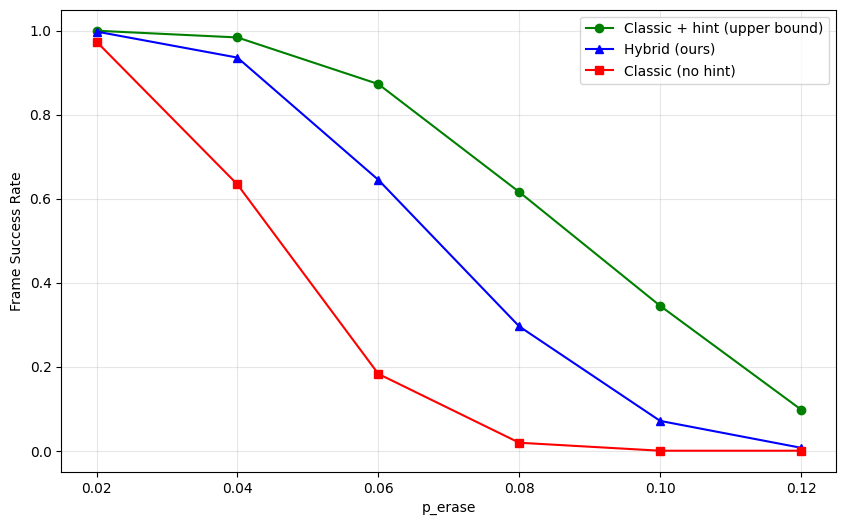

In [ ]:
p_erase = [r['p_erase'] for r in results]
classic = [r['classic'] for r in results]
hybrid = [r['hybrid'] for r in results]
classic_hint = [r['classic_hint'] for r in results]

plt.figure(figsize=(10, 6))
plt.plot(p_erase, classic_hint, 'g-o', label='Classic + hint (upper bound)')
plt.plot(p_erase, hybrid, 'b-^', label='Hybrid (ours)')
plt.plot(p_erase, classic, 'r-s', label='Classic (no hint)')
plt.xlabel('p_erase')
plt.ylabel('Frame Success Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
model.eval()
sample_input, sample_target = dataset[0]
x = torch.tensor(sample_input).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(x)
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

total_ones_target = sample_target.sum()
total_ones_pred = preds.sum().item()
accuracy = ((preds[0].cpu().numpy() == sample_target).sum()) / 255

print(f"Target: {int(total_ones_target)} out of 255")
print(f"Predicted: {int(total_ones_pred)} out of 255")
print(f"Accuracy: {accuracy:.1%}")

Target: 23 out of 255
Predicted: 17 out of 255
Accuracy: 97.6%


In [21]:
target_np = sample_target
pred_np = preds[0].cpu().numpy()

true_positives = ((pred_np == 1) & (target_np == 1)).sum()
false_positives = ((pred_np == 1) & (pred_np == 0)).sum()
false_negatives = ((pred_np == 0) & (target_np == 1)).sum()

recall = true_positives / target_np.sum()
precision = true_positives / pred_np.sum()

print(f'Recall: {recall:.1%} ({int(true_positives)}/{int(target_np.sum())} errors found)')
print(f'Precision: {precision:.1%} ({int(true_positives)}/{int(pred_np.sum())} correct predictions)')
print(f'Missed: {int(false_negatives)} false negatives')
print(f'False pos: {int(false_positives)} false positives')

Recall: 73.9% (17/23 errors found)
Precision: 100.0% (17/17 correct predictions)
Missed: 6 false negatives
False pos: 0 false positives
